# We will generate some data on how the GC preforms

- Incedent angle
- Misalignment

In [ ]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d.web as web
import pickle

from main import (make_sim, get_coupling_efficiency,
                  n_wl, wl_range,source_x)
N_teeth = 9

In [29]:
with open('data/3d_opt/tmp.pkl', 'rb') as f:
    data = pickle.load(f)

widths = data['params'][:-1]
r0 = data['params'][-1]
print(widths,r0)

[0.10171423 0.56965874 0.10788232 0.55931574 0.12239918 0.54603395
 0.14365081 0.53730965 0.17286603 0.52794493 0.19726445 0.51377853
 0.20126376 0.49329495 0.21203213 0.45472557 0.18517969 0.42768282
 0.25428672 0.4253686 ] 4.4967401101567175


In [ ]:
source_xs = np.linspace(source_x-2,source_x+2,5)

# Create all simulations for batch run
sims = {}
for i, src_x in enumerate(source_xs):
    sim_name = f"sim_srcx_{i:02d}"
    sims[sim_name] = make_sim(widths, r0=r0, source_x=src_x, include_field_monitor=False)

# Create and run batch
print(f"Submitting {len(sims)} simulations as a batch...")
batch = web.Batch(simulations=sims, verbose=True)
batch_data = batch.run(
    path_dir='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_3D_4um_Si/data/tidy3d_output',
)

print(f"\nCompleted batch run with {len(batch_data)} simulations")

Output()

Submitting 5 simulations as a batch...


10:38:09 EST Started working on Batch containing 5 tasks.

10:38:15 EST Maximum FlexCredit cost: 1.068 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

10:42:06 EST Batch complete.

Output()


Completed batch run with 5 simulations


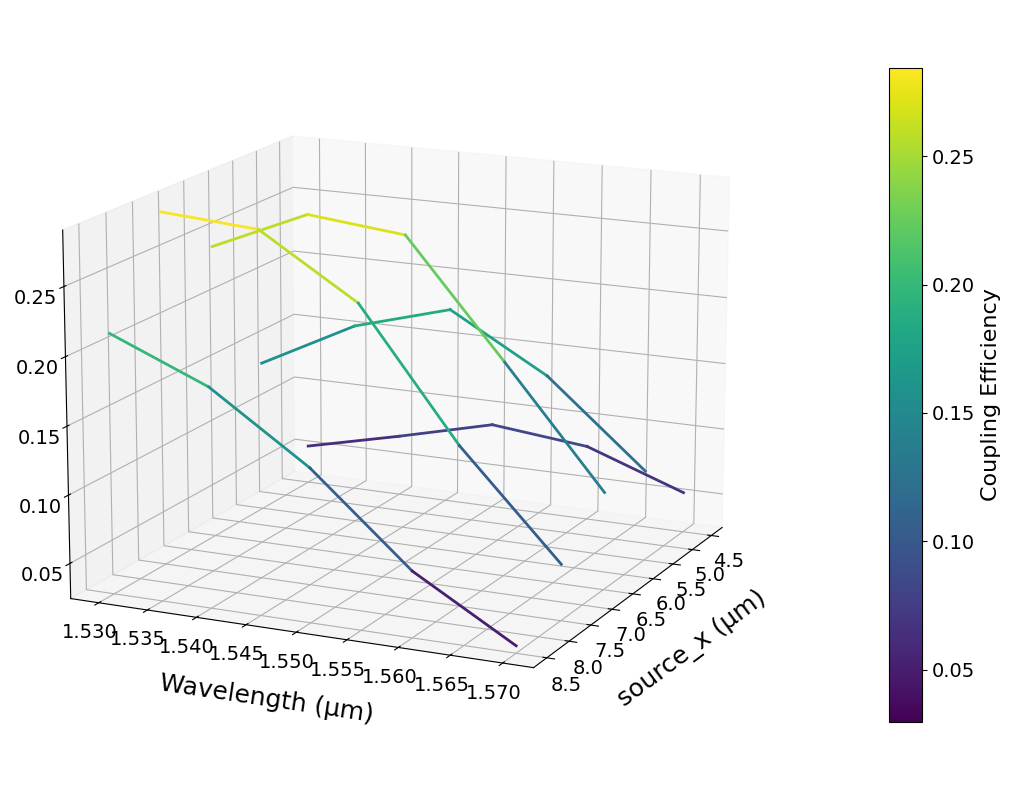

In [40]:
# # Extract coupling efficiency for each simulation
# coupling_effs = []
# for i in range(len(source_xs)):
#     sim_name = f"sim_srcx_{i:02d}"
#     sim_data = batch_data[sim_name]
#     coupling_eff = get_coupling_efficiency(sim_data)
#     coupling_effs.append(coupling_eff)
#     print(coupling_eff)

# You can now change the viewing angle of the 3D plot using 'elev' and 'azim' parameters

coupling_effs = np.array(coupling_effs)  # Shape: (n_source_xs, n_wavelengths)

# Set the viewing angles here:
elev = 15   # elevation angle in the z plane
azim = 25   # azimuthal angle in the x,y plane

# Larger font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 14
colorbar_fontsize = 16
legend_fontsize = 16

# 3D plot: lines colored by z value (i.e., by coupling efficiency)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.view_init(elev=elev, azim=azim)  # Set the view

from matplotlib import cm
from matplotlib.colors import Normalize

norm = Normalize(vmin=np.min(coupling_effs), vmax=np.max(coupling_effs))
cmap = cm.viridis

for i, src_x in enumerate(source_xs):
    zs = coupling_effs[i]
    # Get normalized colors according to z
    colors = cmap(norm(zs))
    for j in range(len(wl_range)-1):
        x_vals = [src_x, src_x]
        y_vals = [wl_range[j], wl_range[j+1]]
        z_vals = [zs[j], zs[j+1]]
        # color according to average z of segment
        col = cmap(norm(0.5*(zs[j] + zs[j+1])))
        ax.plot(x_vals, y_vals, z_vals, color=col, linewidth=2)

# Add colorbar for z coloring
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, pad=0.1, fraction=0.03)
cbar.set_label('Coupling Efficiency', fontsize=colorbar_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# Set labels with increased font sizes
ax.set_xlabel('source_x (μm)', fontsize=label_fontsize, labelpad=16)
ax.set_ylabel('Wavelength (μm)', fontsize=label_fontsize, labelpad=16)
ax.set_zlabel('Coupling Efficiency', fontsize=label_fontsize, labelpad=16)

# Set tick parameters with larger font size
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.tick_params(axis='z', labelsize=tick_fontsize)

plt.tight_layout()
plt.show()

# To change the angle, just edit 'elev' and 'azim' above and rerun the cell.


In [41]:
source_ys = np.linspace(0,2,5)

# Create all simulations for batch run
sims = {}
for i, src_y in enumerate(source_ys):
    sim_name = f"sim_srcx_{i:02d}"
    sims[sim_name] = make_sim(widths, r0=r0, source_y=src_y, include_field_monitor=False)

# Create and run batch
print(f"Submitting {len(sims)} simulations as a batch...")
batch_y = web.Batch(simulations=sims, verbose=True)
batch_data_y = batch_y.run(
    path_dir='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_3D_4um_Si/data/tidy3d_output',
)

print(f"\nCompleted batch run with {len(batch_data)} simulations")

Output()

Submitting 5 simulations as a batch...


11:05:17 EST Started working on Batch containing 5 tasks.

11:05:23 EST Maximum FlexCredit cost: 1.747 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

11:08:22 EST Batch complete.

Output()


Completed batch run with 5 simulations


In [42]:
angles = np.linspace(np.deg2rad(5),np.deg2rad(15),10)

# Create all simulations for batch run
sims = {}
for i, angle in enumerate(angles):
    sim_name = f"sim_srcx_{i:02d}"
    sims[sim_name] = make_sim(widths, r0=r0, source_theta=angle, include_field_monitor=False)

# Create and run batch
print(f"Submitting {len(sims)} simulations as a batch...")
batch_angle = web.Batch(simulations=sims, verbose=True)
batch_data_angle = batch_angle.run(
    path_dir='/Users/dominic/Desktop/fdtd/testing/PhotonicComponents/GC_3D_4um_Si/data/tidy3d_output',
)

print(f"\nCompleted batch run with {len(batch_data)} simulations")

Output()

Submitting 10 simulations as a batch...


11:08:42 EST Started working on Batch containing 10 tasks.

11:08:52 EST Maximum FlexCredit cost: 1.968 for the whole batch.

             Use 'Batch.real_cost()' to get the billed FlexCredit cost after the
             Batch has completed.

Output()

11:10:30 EST Batch complete.

Output()


Completed batch run with 5 simulations


[0.24310917 0.27428701 0.26673946 0.18217383 0.09587042]
[0.22734005 0.25569053 0.24888831 0.16937738 0.0893034 ]
[0.18517568 0.20771923 0.20167985 0.13662708 0.07166329]
[0.13152741 0.1468299  0.14205977 0.09540431 0.04961673]
[0.08138909 0.09040227 0.08692642 0.05769178 0.02954922]


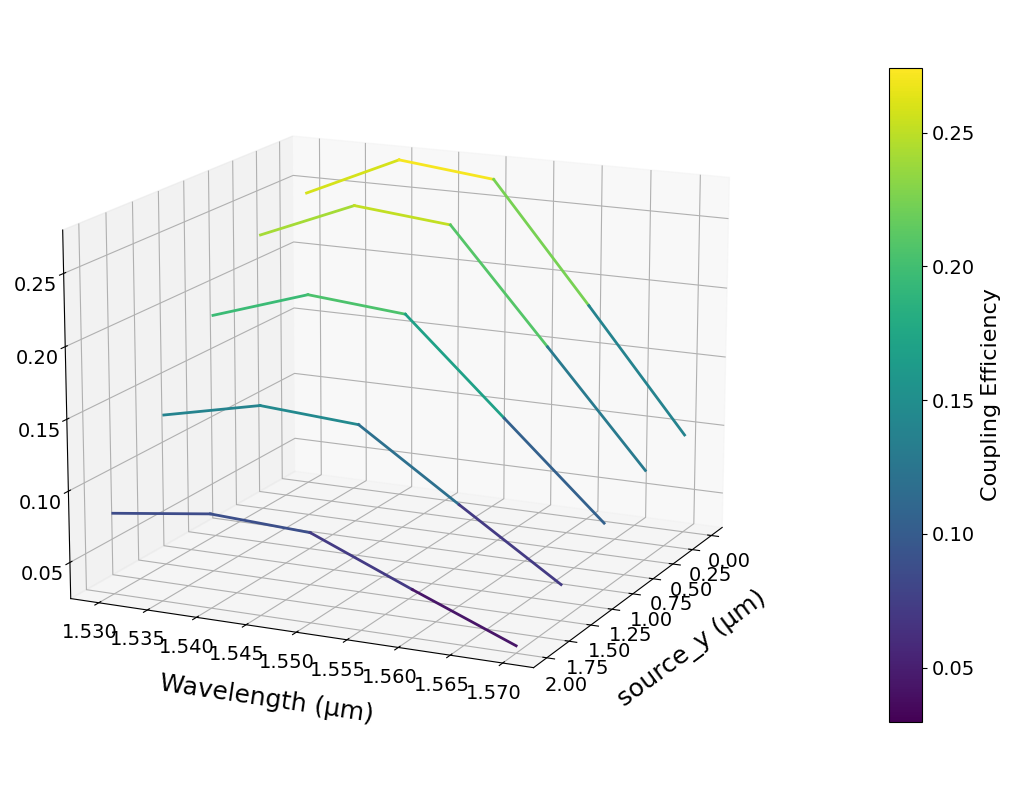

In [45]:
# Extract coupling efficiency for each simulation (for y-shift sweep)
coupling_effs = []
for i, src_y in enumerate(source_ys):
    sim_name = f"sim_srcx_{i:02d}"
    sim_data = batch_data_y[sim_name]
    coupling_eff = get_coupling_efficiency(sim_data)
    coupling_effs.append(coupling_eff)
    print(coupling_eff)

coupling_effs = np.array(coupling_effs)  # Shape: (n_source_ys, n_wavelengths)

# Set the viewing angles here:
elev = 15   # elevation angle in the z plane
azim = 25   # azimuthal angle in the x,y plane

# Larger font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 14
colorbar_fontsize = 16
legend_fontsize = 16

# 3D plot: lines colored by z value (i.e., by coupling efficiency)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.view_init(elev=elev, azim=azim)  # Set the view

from matplotlib import cm
from matplotlib.colors import Normalize

norm = Normalize(vmin=np.min(coupling_effs), vmax=np.max(coupling_effs))
cmap = cm.viridis

for i, src_y in enumerate(source_ys):
    zs = coupling_effs[i]
    # Get normalized colors according to z
    colors = cmap(norm(zs))
    for j in range(len(wl_range)-1):
        x_vals = [src_y, src_y]
        y_vals = [wl_range[j], wl_range[j+1]]
        z_vals = [zs[j], zs[j+1]]
        # color according to average z of segment
        col = cmap(norm(0.5*(zs[j] + zs[j+1])))
        ax.plot(x_vals, y_vals, z_vals, color=col, linewidth=2)

# Add colorbar for z coloring
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, pad=0.1, fraction=0.03)
cbar.set_label('Coupling Efficiency', fontsize=colorbar_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# Set labels with increased font sizes
ax.set_xlabel('source_y (μm)', fontsize=label_fontsize, labelpad=16)
ax.set_ylabel('Wavelength (μm)', fontsize=label_fontsize, labelpad=16)
ax.set_zlabel('Coupling Efficiency', fontsize=label_fontsize, labelpad=16)

# Set tick parameters with larger font size
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.tick_params(axis='z', labelsize=tick_fontsize)

plt.tight_layout()
plt.show()

# To change the angle, just edit 'elev' and 'azim' above and rerun the cell.


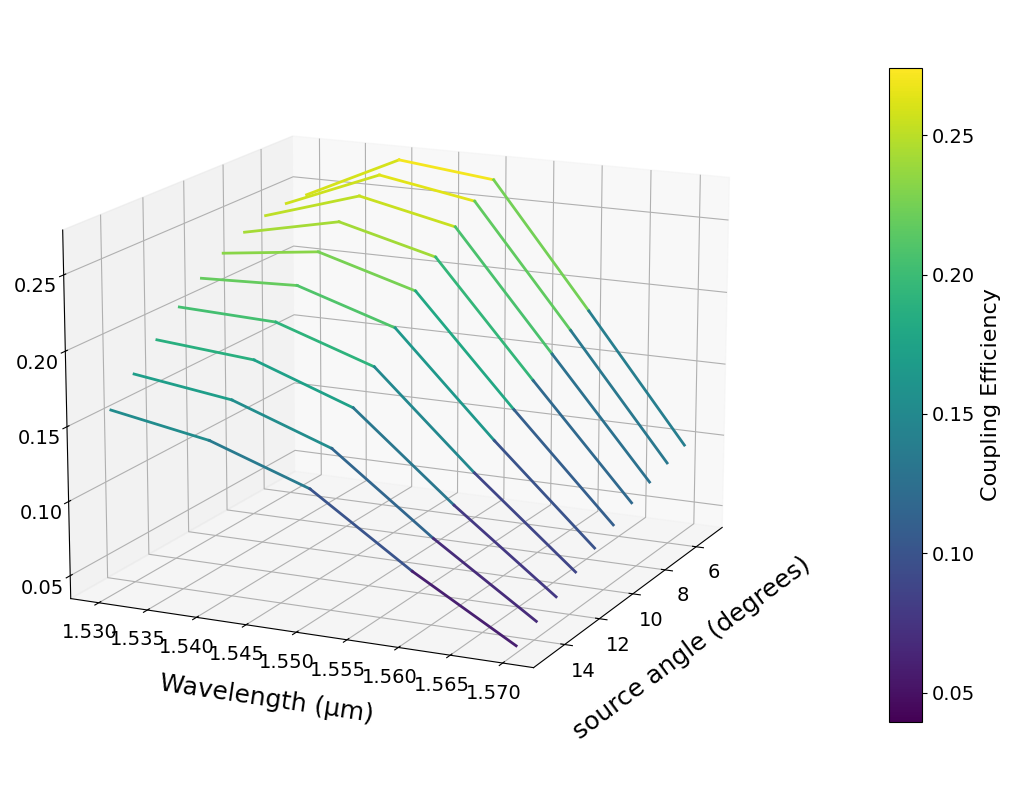

In [48]:
# # Extract coupling efficiency for each simulation (loop over angles now)
# coupling_effs = []
# for i in range(len(angles)):
#     sim_name = f"sim_srcx_{i:02d}"
#     sim_data = batch_data_angle[sim_name]
#     coupling_eff = get_coupling_efficiency(sim_data)
#     coupling_effs.append(coupling_eff)
#     print(coupling_eff)

# You can now change the viewing angle of the 3D plot using 'elev' and 'azim' parameters

coupling_effs = np.array(coupling_effs)  # Shape: (n_angles, n_wavelengths)

# Set the viewing angles here:
elev = 15   # elevation angle in the z plane
azim = 25   # azimuthal angle in the x,y plane

# Larger font sizes
label_fontsize = 18
title_fontsize = 20
tick_fontsize = 14
colorbar_fontsize = 16
legend_fontsize = 16

# 3D plot: lines colored by z value (i.e., by coupling efficiency)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.view_init(elev=elev, azim=azim)  # Set the view

from matplotlib import cm
from matplotlib.colors import Normalize

norm = Normalize(vmin=np.min(coupling_effs), vmax=np.max(coupling_effs))
cmap = cm.viridis

for i, angle in enumerate(angles):
    zs = coupling_effs[i]
    # Get normalized colors according to z
    colors = cmap(norm(zs))
    for j in range(len(wl_range)-1):
        x_vals = [np.degrees(angle), np.degrees(angle)]
        y_vals = [wl_range[j], wl_range[j+1]]
        z_vals = [zs[j], zs[j+1]]
        # color according to average z of segment
        col = cmap(norm(0.5*(zs[j] + zs[j+1])))
        ax.plot(x_vals, y_vals, z_vals, color=col, linewidth=2)

# Add colorbar for z coloring
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cbar = plt.colorbar(mappable, ax=ax, pad=0.1, fraction=0.03)
cbar.set_label('Coupling Efficiency', fontsize=colorbar_fontsize)
cbar.ax.tick_params(labelsize=tick_fontsize)

# Set labels with increased font sizes
ax.set_xlabel('source angle (degrees)', fontsize=label_fontsize, labelpad=16)
ax.set_ylabel('Wavelength (μm)', fontsize=label_fontsize, labelpad=16)
ax.set_zlabel('Coupling Efficiency', fontsize=label_fontsize, labelpad=16)

# Set tick parameters with larger font size
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.tick_params(axis='z', labelsize=tick_fontsize)

plt.tight_layout()
plt.show()

# To change the viewing angle, just edit 'elev' and 'azim' above and rerun the cell.


In [52]:
sim = make_sim(widths, r0=r0, source_y=0.1, include_field_monitor=False)

<Axes: title={'center': 'cross section at z=0.00 (μm)'}, xlabel='x (μm)', ylabel='y (μm)'>

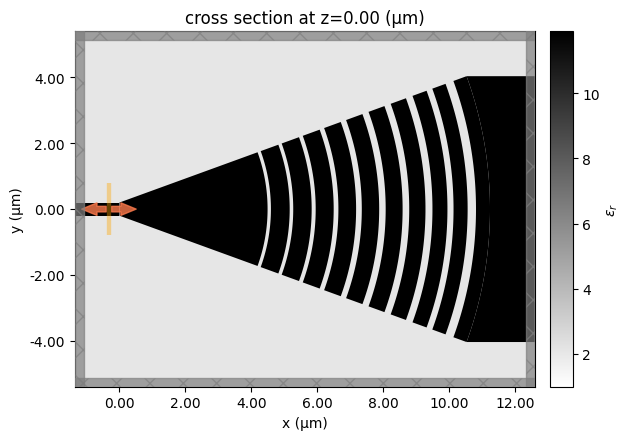

In [53]:
sim.plot_eps(z=0)